# Notebook 09: Map of Domain, noteable features and fires

## Imports

In [1]:
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


import numpy as np
import rioxarray
import xarray as xr

import geopandas as gpd
from pyhdf.SD import SD, SDC
from rasterio.transform import from_bounds
from shapely.geometry import box

import cartopy.crs as ccrs
import cartopy.feature as cfeature; 

warnings.filterwarnings("ignore")

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
out_dir = "./plots/"

## Get and prepare data

### Grid

In [3]:
grid = xr.open_dataset("./data/grids/hra_DOM01.nc",engine="netcdf4")

lon = np.rad2deg(grid.clon)
lat = np.rad2deg(grid.clat)

lon_min = lon.min()
lon_max = lon.max()
lat_min = lat.min()
lat_max = lat.max()

### Topography

In [4]:
topo = xr.open_dataset("./data/grids/topo.nc").topo

### Fire Shape

In [5]:

gdf = gpd.read_file("./data/obs/HistoricalWildfirePerimeters.shp")

In [6]:
gdf_2025 = (gdf[gdf["YEAR"] == 2025].to_crs("EPSG:4326"))
gdf_2025_large = gdf_2025[gdf_2025["HECTARES_U"] >= 100].copy()

print("Number of 2025 fires:", len(gdf_2025))
print("Number of large fires:", len(gdf_2025_large))

Number of 2025 fires: 397
Number of large fires: 68


### Modis FRP Observations

In [7]:
path_fires = "./data/modis/modis_regridded.nc" 
fires  = xr.open_mfdataset(path_fires, engine='netcdf4')
threshold = 100

In [8]:
frp = fires.frp.sel(time=np.datetime64("2025-05-30 00:00:00"),method="nearest",)

mask = (frp >= threshold).compute()

fire_frp = frp.where(mask, drop=True)
fire_lons = lon.where(mask, drop=True)
fire_lats = lat.where(mask, drop=True)

## Lightning Data

In [9]:
# Lightning data
lpath = "./data/obs/*flashes_3hr_0.1-deg_2025.nc"

# Load lightning data
time_slice = slice(
    "2025-05-29T23:00:00",
    "2025-05-30T01:00:00"
)

l = xr.open_mfdataset(lpath).sel(time=time_slice).squeeze()

In [10]:
flash = (l.cg_flashes + l.cc_flashes)
fmask = flash.values > 1

flon2d, flat2d = np.meshgrid(
    l.lon.values,
    l.lat.values
)


flons = flon2d[fmask]
flats = flat2d[fmask]


## Plot

In [11]:
# =================================================
# Plot settings
# =================================================

# Figure
fsize = 18
figsize = (22, 8)

# Map layout
width_ratios = [1.3, 1]
wspace = 0.08

# Map extends
central_lon = lon.mean()
central_lat = lat.mean()

# Main map extent
dlon = 8
dlat = 6

maplon_min = central_lon - dlon
maplon_max = central_lon + dlon
maplat_min = central_lat - dlat
maplat_max = central_lat + dlat

# Zoom map extent
zoom_extent = 1.5

# Circles
fire_radius = 1.0
away_radius = 1.0
zoom_radius = 1.0

fire_lon_away = -113.8
fire_lat_away = 53.9

fire_lon = -113.8
fire_lat = 56.9

# Stations
radar_lon = -111.2
radar_lat = 56.37

sounding_lon = -111.9
sounding_lat = 60.0

# Lightning
lmarker_size = 5
lmarker_shape = "X"

# Topography
topo_levels = np.arange(100, 2300, 50)

topo_cmap = LinearSegmentedColormap.from_list(
    "terrain_half",
    plt.get_cmap("gist_earth")(np.linspace(0.4, 1, 256))
)

# Plot styling
perimeter_color = "red"
frp_color = "firebrick"
station_color = "purple"

gridline_color = "0.5"
away_circle_color = "lightgrey"

perimeter_lw = 0.8
zoom_perimeter_lw = 1.0
station_size = 120
sounding_size = 90
frp_size = 7

coastline_lw = 0.8
state_lw = 0.6
gridline_lw = 0.5

# Fire perimeter labels
label_area_threshold = 1000
label_fontsize = 13

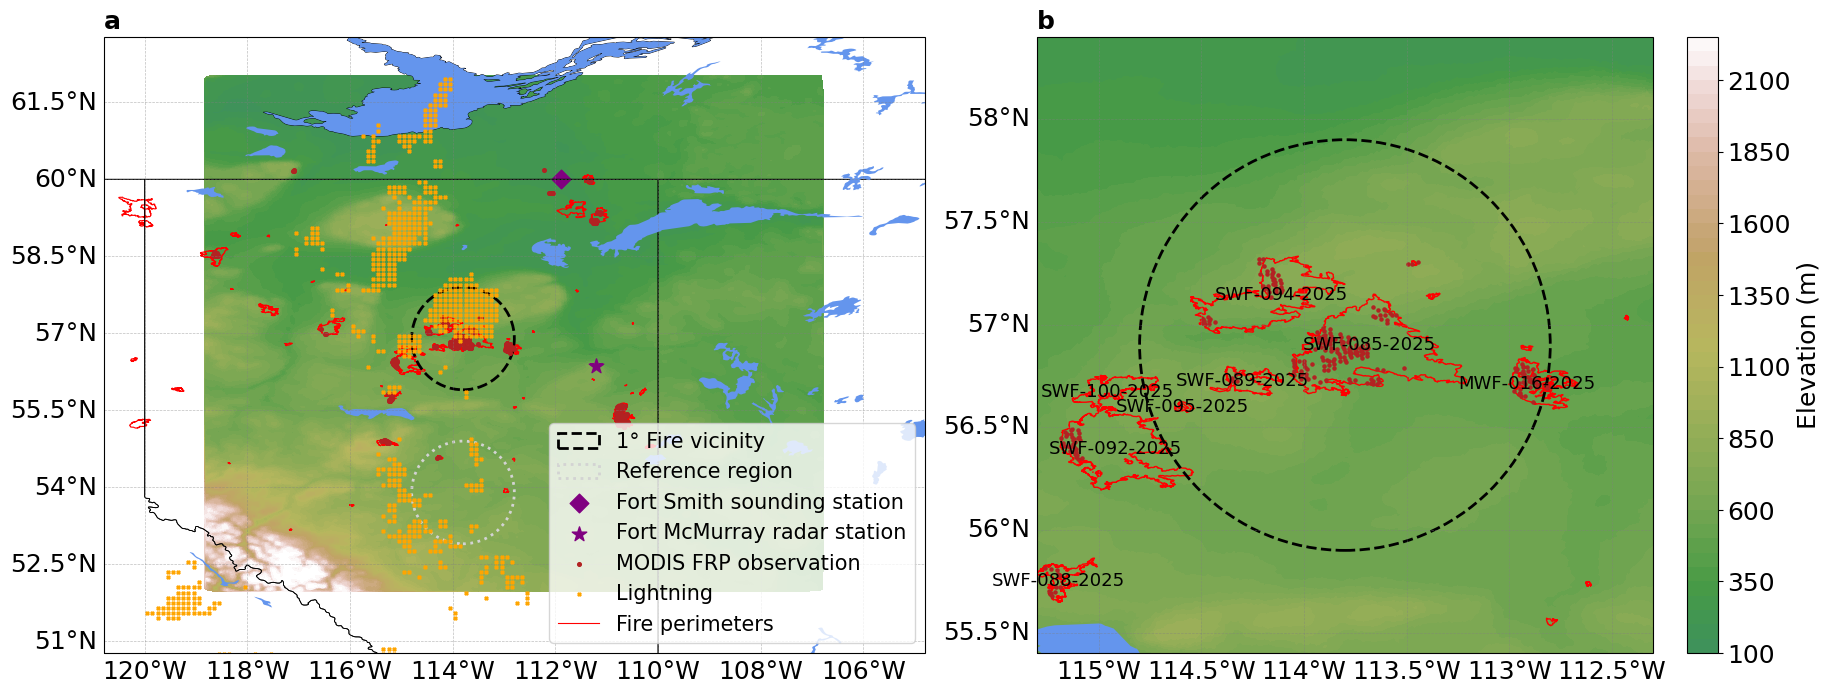

In [12]:
# =================================================
# Figure
# =================================================

fig = plt.figure(figsize=figsize)

gs = fig.add_gridspec(
    1,
    2,
    width_ratios=width_ratios,
    wspace=wspace,
)

ax = fig.add_subplot(
    gs[0],
    projection=ccrs.PlateCarree(),
)

ax_zoom = fig.add_subplot(
    gs[1],
    projection=ccrs.PlateCarree(),
)



# -------------------------------------------------
# Topography
# -------------------------------------------------

topo_im = ax.tricontourf(
    lon,
    lat,
    topo,
    levels=topo_levels,
    cmap=topo_cmap,
    transform=ccrs.PlateCarree(),
)

ax_zoom.tricontourf(
    lon,
    lat,
    topo,
    levels=topo_levels,
    cmap=topo_cmap,
    transform=ccrs.PlateCarree(),
)


# -------------------------------------------------
# 2025 wildfire perimeters
# -------------------------------------------------

gdf_2025_large.plot(
    ax=ax,
    facecolor="none",
    edgecolor=perimeter_color,
    linewidth=perimeter_lw,
    transform=ccrs.PlateCarree(),
    label="Fire perimeters",
)

gdf_2025_large.plot(
    ax=ax_zoom,
    facecolor="none",
    edgecolor=perimeter_color,
    linewidth=zoom_perimeter_lw,
    transform=ccrs.PlateCarree(),
)


# -------------------------------------------------
# Fire perimeter labels
# -------------------------------------------------

label_area_threshold = 1000

zoom_box = box(
    fire_lon - zoom_extent,
    fire_lat - zoom_extent,
    fire_lon + zoom_extent,
    fire_lat + zoom_extent,
)

gdf_labels = gdf_2025[
    gdf_2025["HECTARES_U"] >= label_area_threshold
].copy()

gdf_labels = gdf_labels[
    gdf_labels.geometry.intersects(zoom_box)
]

for _, fire in gdf_labels.iterrows():

    point = fire.geometry.representative_point()

    ax_zoom.text(
        point.x,
        point.y,
        str(fire["FIRENUMBER"]),
        transform=ccrs.PlateCarree(),
        fontsize=label_fontsize,
        ha="center",
        va="center",
        zorder=150,
    )


# -------------------------------------------------
# Fire and away-from-fire areas
# -------------------------------------------------

ax.add_patch(
    plt.Circle(
        (fire_lon, fire_lat),
        fire_radius,
        transform=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=2,
        linestyle="--",
        label="1° Fire vicinity",
    )
)

ax.add_patch(
    plt.Circle(
        (fire_lon_away, fire_lat_away),
        away_radius,
        transform=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor=away_circle_color,
        linewidth=2,
        linestyle=":",
        label="Reference region",
    )
)

ax_zoom.add_patch(
    plt.Circle(
        (fire_lon, fire_lat),
        zoom_radius,
        transform=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=2,
        linestyle="--",
    )
)


# -------------------------------------------------
# Map features
# -------------------------------------------------

for axis in [ax, ax_zoom]:

    axis.add_feature(
        cfeature.COASTLINE,
        linewidth=coastline_lw,
    )

    axis.add_feature(
        cfeature.STATES,
        linewidth=state_lw,
    )

    axis.add_feature(
        cfeature.LAKES,
        facecolor="cornflowerblue",
    )


# -------------------------------------------------
# Stations
# -------------------------------------------------

ax.scatter(
    sounding_lon,
    sounding_lat,
    s=sounding_size,
    c=station_color,
    marker="D",
    label="Fort Smith sounding station",
)

ax.scatter(
    radar_lon,
    radar_lat,
    s=station_size,
    c=station_color,
    marker="*",
    label="Fort McMurray radar station",
)


# -------------------------------------------------
# MODIS FRP observations
# -------------------------------------------------

ax.scatter(
    fire_lons,
    fire_lats,
    c=frp_color,
    s=frp_size,
    transform=ccrs.PlateCarree(),
    label="MODIS FRP observation",
)

ax_zoom.scatter(
    fire_lons,
    fire_lats,
    c=frp_color,
    s=5,
    transform=ccrs.PlateCarree(),
)


# -------------------------------------------------
# Lightning
# -------------------------------------------------

ax.scatter(
    flons,
    flats,
    s=lmarker_size,
    marker=lmarker_shape,
    c="Orange",
    transform=ccrs.PlateCarree(),
    label="Lightning",
    zorder=100,
)


# -------------------------------------------------
# Gridlines
# -------------------------------------------------

gl = ax.gridlines(
    draw_labels=True,
    linewidth=gridline_lw,
    color=gridline_color,
    alpha=0.5,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": fsize}
gl.ylabel_style = {"size": fsize}


gl_zoom = ax_zoom.gridlines(
    draw_labels=True,
    linewidth=gridline_lw,
    color=gridline_color,
    alpha=0.5,
    linestyle="--",
)

gl_zoom.top_labels = False
gl_zoom.right_labels = False
gl_zoom.left_labels = True
gl_zoom.xlabel_style = {"size": fsize}
gl_zoom.ylabel_style = {"size": fsize}


# -------------------------------------------------
# Map extents
# -------------------------------------------------

ax.set_extent(
    [maplon_min, maplon_max, maplat_min, maplat_max],
    crs=ccrs.PlateCarree(),
)

ax_zoom.set_extent(
    [
        fire_lon - zoom_extent,
        fire_lon + zoom_extent,
        fire_lat - zoom_extent,
        fire_lat + zoom_extent,
    ],
    crs=ccrs.PlateCarree(),
)


# -------------------------------------------------
# Topography colorbar
# -------------------------------------------------

cbar_topo = fig.colorbar(
    topo_im,
    ax=[ax, ax_zoom],
    orientation="vertical",
    pad=0.02,
    fraction=0.045,
)

cbar_topo.set_label(
    "Elevation (m)",
    fontsize=fsize,
)

cbar_topo.ax.tick_params(
    labelsize=fsize,
)


# -------------------------------------------------
# Legend
# -------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

handles.append(
    Line2D(
        [0],
        [0],
        color=perimeter_color,
        linewidth=perimeter_lw,
    )
)

labels.append("Fire perimeters")

legend = ax.legend(
    handles,
    labels,
    fontsize=fsize - 3,
    loc="lower right",
)

legend.set_zorder(200)


# -------------------------------------------------
# Panel labels
# -------------------------------------------------

ax.set_title(
    "a",
    fontsize=fsize,
    loc="left",
    fontweight="bold",
)

ax_zoom.set_title(
    "b",
    fontsize=fsize,
    loc="left",
    fontweight="bold",
)

# -------------------------------------------------
# Map aspect ratio
# -------------------------------------------------

ax.set_aspect("equal")
ax_zoom.set_aspect("equal")

# -------------------------------------------------
# Save
# -------------------------------------------------

plt.show()

fig.savefig(
    out_dir + "domain_map.png",
    dpi=300,
    bbox_inches="tight",
)